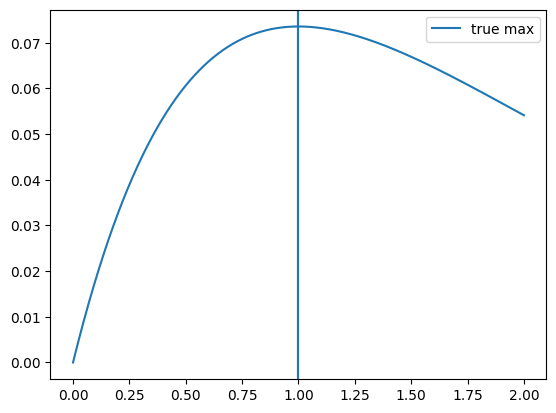

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_35107/3335875845.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)


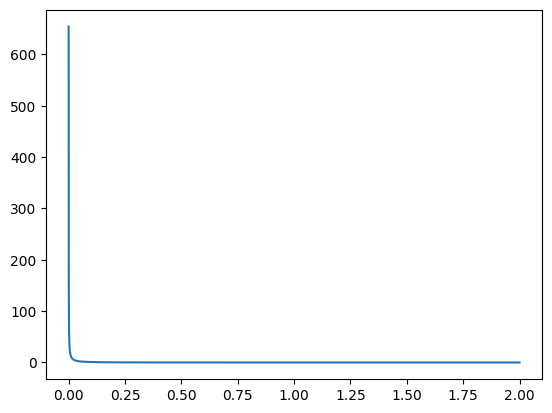

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_35107/3335875845.py:33: RuntimeWarning: invalid value encountered in scalar multiply
  mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,0.131*10)*omega for omega in omegas]


[1.00010001]
1


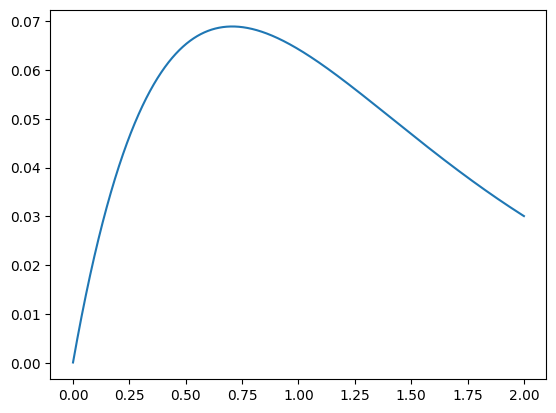

In [2]:
# looking at behaviour of spectral densities and rates for different T
import numpy as np
import matplotlib.pyplot as plt

alpha=0.1
omega_c=1
zeta=1

def spectral_density(omega,zeta):
    return 2*alpha*(omega/omega_c)**zeta *omega_c * np.exp(-omega/omega_c)

omegas=np.linspace(0,2*zeta*omega_c,10000)


density_vals=[spectral_density(omega,zeta) for omega in omegas]
maximum_j = max(density_vals)
pos_max= np.where(density_vals==maximum_j)

plt.plot(omegas,density_vals)
plt.axvline(omegas[pos_max],label='true max')
plt.axvline(zeta*omega_c)
plt.legend()
plt.show()

def bose_einstein(omega,T):
    beta=1/T
    return 1/(np.exp(beta*omega)-1)

bose_vals=[bose_einstein(omega,0.131) for omega in omegas]
plt.plot(omegas,bose_vals)
plt.show()

mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,0.131*10)*omega for omega in omegas]

plt.plot(omegas,mult)
print(omegas[pos_max])
print(zeta*omega_c)

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_11581/2903198796.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_11581/2659170735.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  return np.pi * alpha * (1+bose_einstein(omega,T)) * spectral_density(omega,zeta)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_11581/2659170735.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return np.pi * alpha * bose_einstein(omega,T) * spectral_density(omega,zeta)


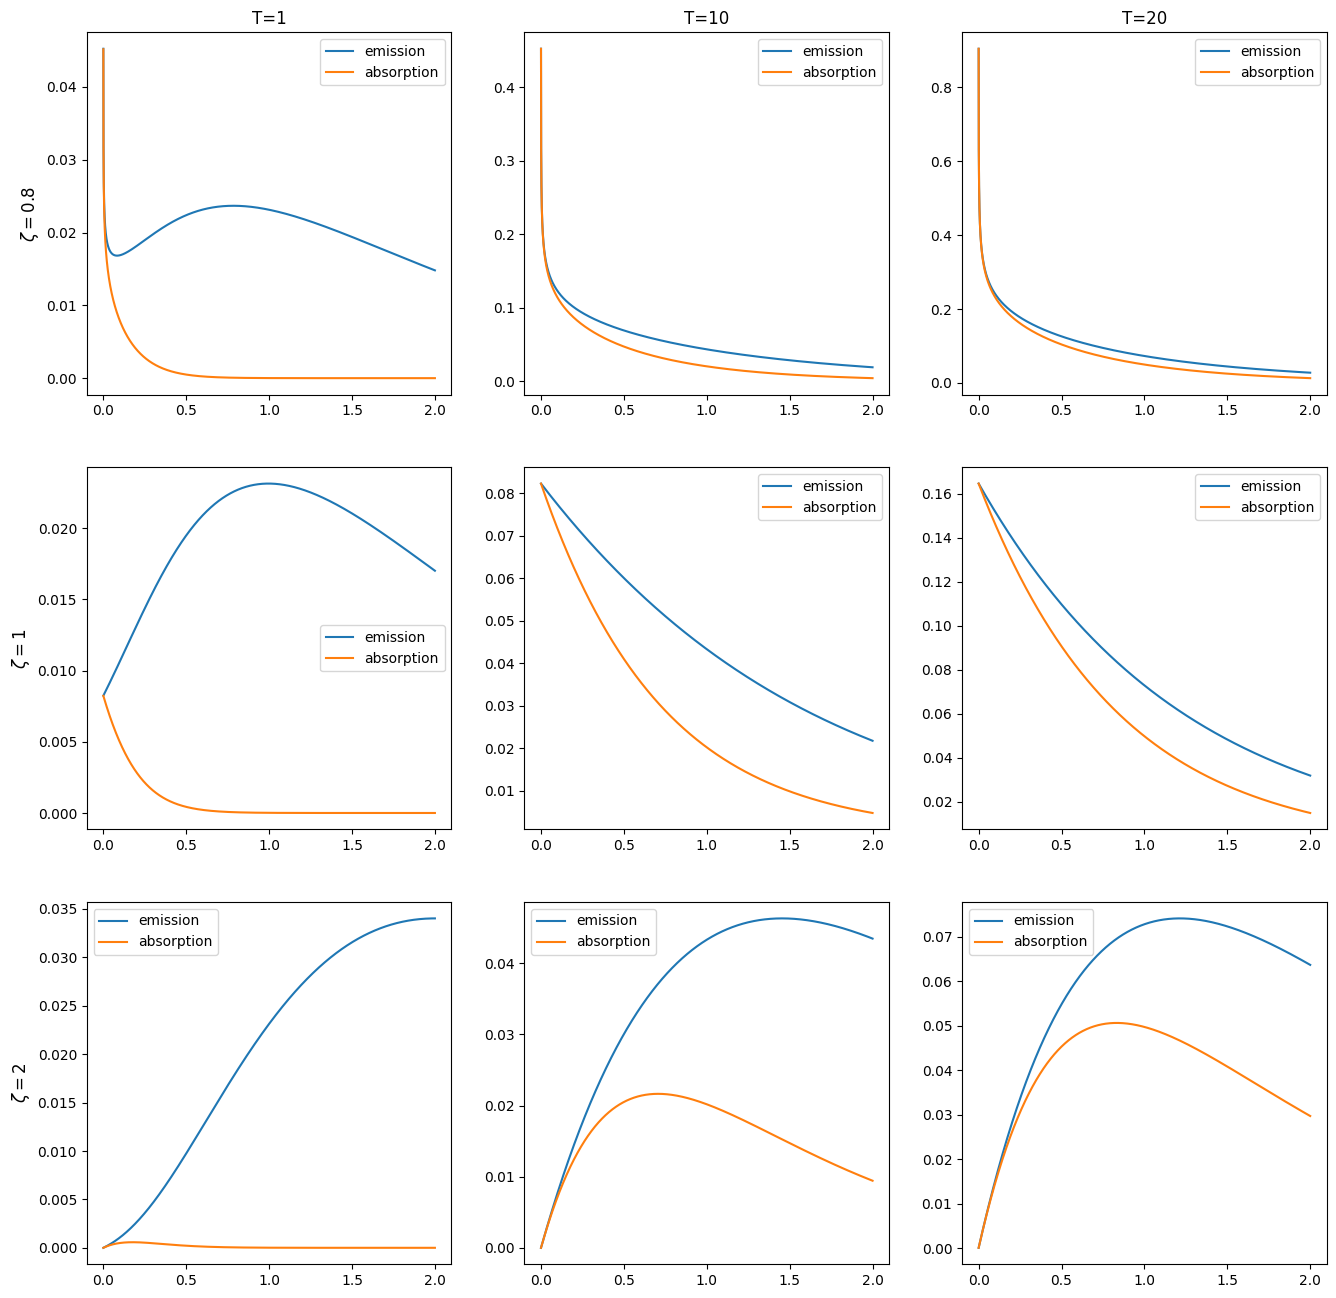

In [4]:
def emission_rate(omega,T,zeta):
    return np.pi * alpha * (1+bose_einstein(omega,T)) * spectral_density(omega,zeta)

def absorption_rate(omega,T,zeta):
    return np.pi * alpha * bose_einstein(omega,T) * spectral_density(omega,zeta)

zeta_vals=[0.8,1,2]
temperatures=[1,10,20]

cols = ['T={}'.format(col) for col in temperatures]
rows = ['$\zeta={}$'.format(row) for row in zeta_vals]

fig,axs=plt.subplots(nrows=3,ncols=3,figsize=(16,16))


for i,zeta in enumerate(zeta_vals):
    for j,temp in enumerate(temperatures):
        rates_e=[emission_rate(omega,temp*0.131,zeta) for omega in omegas]
        rates_a = [absorption_rate(omega,temp*0.131,zeta) for omega in omegas]

        axs[i,j].plot(omegas,rates_e,label='emission')
        axs[i,j].plot(omegas,rates_a,label='absorption')
        axs[i,j].legend()

for ax, col in zip(axs[0], cols):
    ax.set_title(col)

for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(row, rotation=90, size='large')
    
plt.legend()
plt.show()

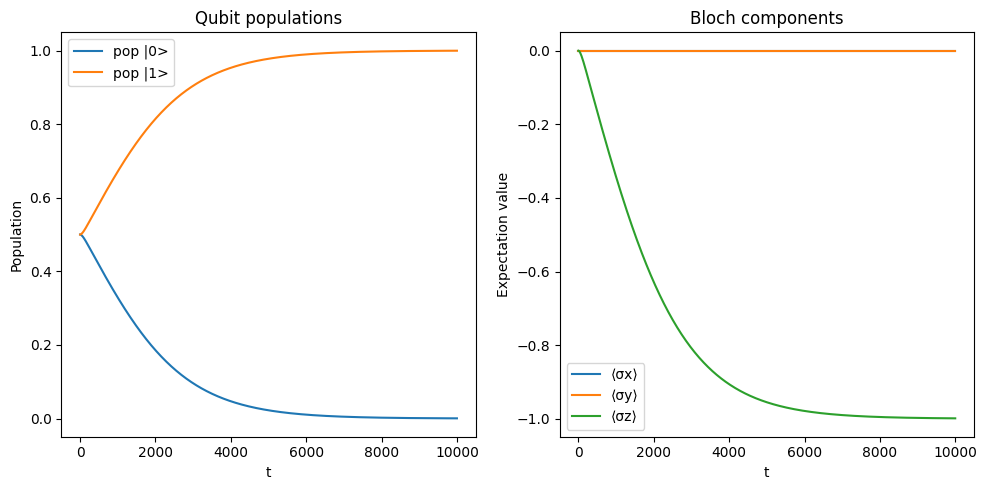

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
si = np.eye(2, dtype=complex)

dim=2

temperature=0.131 # inverse picoseconds

# Collapse operators: relaxation and excitation
sm = np.array([[0, 0], [1, 0]], dtype=complex)
sp = np.array([[0, 1], [0, 0]], dtype=complex)
zeta=1
def solve_lindblad(omega_func, rho0, omega0,t_span, t_eval=None):
    """
    Solve Lindblad equation with time-dependent Hamiltonian.
    H_func(t) should return the Hamiltonian at time t.
    """
    dim = rho0.shape[0]

    def rhs(t, y):
        Ht = omega_func(omega0, t) * sz /2 

        I = np.eye(dim, dtype=complex)
        
        # Hamiltonian contribution
        L_H = -1j * (np.kron(I, Ht) - np.kron(Ht.T, I))
        
        # Time-dependent collapse rates
        gamma_relax_t = emission_rate(omega_func(omega0,t), temperature, zeta)
        gamma_excite_t = absorption_rate(omega_func(omega0,t), temperature, zeta)
        
        # Collapse operators
        L_diss_t = np.zeros((dim*dim, dim*dim), dtype=complex)
        for C, rate in [(sm, gamma_relax_t), (sp, gamma_excite_t)]:
            CdC = C.conj().T @ C
            L_diss_t += rate * np.kron(C.conj(), C)
            L_diss_t += -0.5 * rate * np.kron(I, CdC)
            L_diss_t += -0.5 * rate * np.kron(CdC.T, I)
        
        return (L_H + L_diss_t) @ y
    
    y0 = rho0.reshape(dim*dim, order='F')
    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45',
                    atol=1e-9, rtol=1e-7)

    rhos = [sol.y[:, i].reshape((dim, dim), order='F')
            for i in range(sol.y.shape[1])]
    return sol.t, rhos

# Initial state: maximally mixed state
rho0 = np.array([[1/2, 0], [0, 1/2]], dtype=complex)

def omega_t(omega0,t):
    return omega0 * t +0.0001

t_max = 10000
omega0=omega_c/t_max

t_eval = np.linspace(0, t_max, 600)
t, rhos = solve_lindblad(omega_t, rho0, omega0,(0, t_max), t_eval=t_eval)

# Observables
pop0 = np.real([np.trace(rho @ np.array([[1,0],[0,0]])) for rho in rhos])
pop1 = np.real([np.trace(rho @ np.array([[0,0],[0,1]])) for rho in rhos])
sx_exp = np.real([np.trace(rho @ sx) for rho in rhos])
sy_exp = np.real([np.trace(rho @ sy) for rho in rhos])
sz_exp = np.real([np.trace(rho @ sz) for rho in rhos])

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(t, pop0, label='pop |0>')
plt.plot(t, pop1, label='pop |1>')
plt.xlabel('t')
plt.ylabel('Population')
plt.legend()
plt.title('Qubit populations')

plt.subplot(1,2,2)
plt.plot(t, sx_exp, label=r'⟨σx⟩')
plt.plot(t, sy_exp, label=r'⟨σy⟩')
plt.plot(t, sz_exp, label=r'⟨σz⟩')
plt.xlabel('t')
plt.ylabel('Expectation value')
plt.legend()
plt.title('Bloch components')

plt.tight_layout()
plt.show()


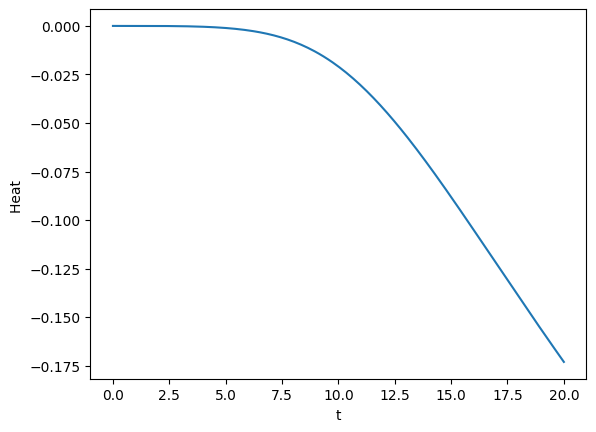

In [38]:
from scipy.integrate import cumulative_trapezoid

def compute_heat(t_points, rhos, omega_func, omega0):
    """Compute heat current Tr(rhodot H) at sampled times."""
    heat_currs = []
    dim = rhos[0].shape[0]

    for ti, rho in zip(t_points, rhos):
        Ht = omega_func(omega0, ti) * sz / 2
        Ht_vec = Ht.reshape(dim*dim, order="F")
        rho_vec = rho.reshape(dim*dim, order="F")

        # Construct Liouvillian at this time
        I = np.eye(dim, dtype=complex)
        L_H = -1j * (np.kron(I, Ht) - np.kron(Ht.T, I))

        gamma_relax_t = emission_rate(omega_func(omega0, ti), temperature, zeta)
        gamma_excite_t = absorption_rate(omega_func(omega0, ti), temperature, zeta)

        L_diss_t = np.zeros((dim*dim, dim*dim), dtype=complex)
        for C, rate in [(sm, gamma_relax_t), (sp, gamma_excite_t)]:
            CdC = C.conj().T @ C
            L_diss_t += rate * np.kron(C.conj(), C)
            L_diss_t += -0.5 * rate * np.kron(I, CdC)
            L_diss_t += -0.5 * rate * np.kron(CdC.T, I)

        L = L_H + L_diss_t

        rhodot = L @ rho_vec
        qdot = np.vdot(Ht_vec, rhodot).real   # ⟨Ht, rhodot⟩
        heat_currs.append(qdot)

    Q = cumulative_trapezoid(heat_currs, t_points, initial=0.0)
    return Q


t, rhos = solve_lindblad(omega_t, rho0, omega0, (0, t_max), t_eval=t_eval)
heats = compute_heat(t, rhos, omega_t, omega0)

plt.plot(t, heats)
plt.xlabel("t")
plt.ylabel("Heat ")
plt.show()


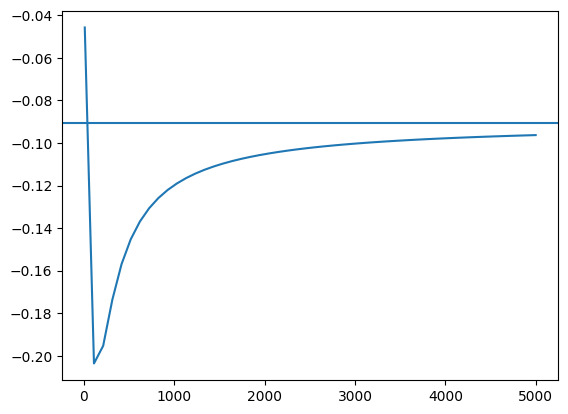

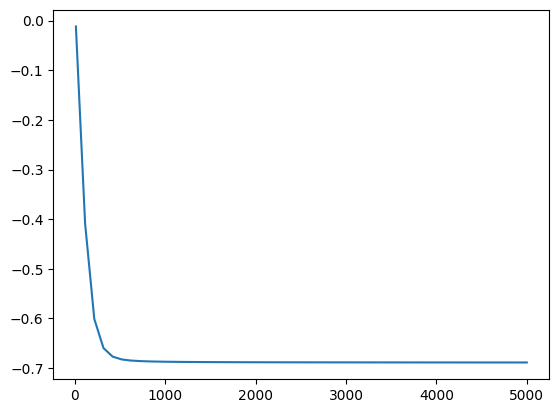

In [ ]:

def entropy(rho):
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, 1e-14, 1.0)
    return -np.sum(evals * np.log(evals))

def compute_entropy_change(rhos):
    S0 = entropy(rhos[0])
    return np.array([entropy(rho) - S0 for rho in rhos])

omega0=omega_c

def linear_ramp(omega0,tprot,t):
    return omega0 * t/tprot +0.0001

def geodesic(omega0,tprot,t):
    return omega0*(t/tprot-np.sin(2*np.pi*t/tprot)/(2*np.pi)) + 0.0001

final_times=np.linspace(10,5000,50)
final_heats=np.zeros((2,50))
final_entropys=np.zeros((2,50))

for i,omega_func in enumerate([linear_ramp,geodesic]):
    for j,t_max in enumerate(final_times):
        omega0=omega_c
        
        omega_t=lambda omega0,t : omega_func(omega0,t_max,t)
        t_eval = np.linspace(0, t_max, 600)
        t, rhos = solve_lindblad(omega_t, rho0, omega0,(0, t_max))

        entropy_change=compute_entropy_change(rhos)
        final_entropys[i,j]=entropy_change[-1]

        heats = compute_heat(t, rhos, omega_t, omega0)
        final_heats[i,j]=heats[-1]

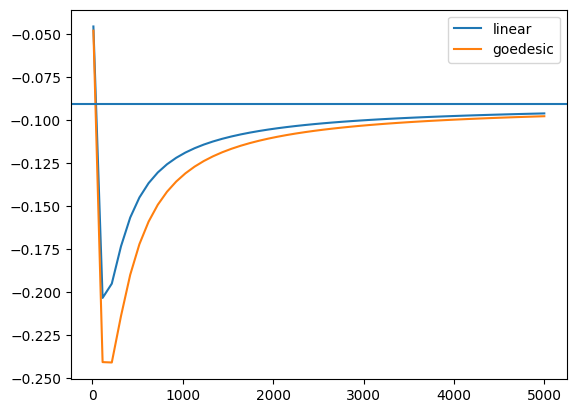

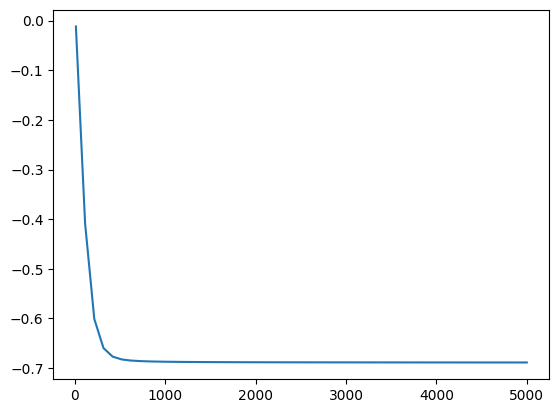

In [ ]:
plt.plot(final_times,final_heats[0,:],label="linear")
plt.plot(final_times,final_heats[1,:],label="geodesic")
plt.axhline(-temperature*np.log(2))
plt.legend()
plt.show()

plt.plot(final_times,final_entropys[0,:])


In [ ]:
import numpy as np
from scipy.optimize import minimize

# --- Parametrization of omega(t) ---
def make_omega_func(params, t_max):
    N = len(params)
    dt = t_max / N
    def omega_func(omega0, t):
        idx = min(int(t // dt), N-1)
        return params[idx]
    return omega_func

# --- Cost function (final heat) ---
def cost(params, rho0, omega0, t_max, t_eval):
    omega_func = make_omega_func(params, t_max)
    t, rhos = solve_lindblad(omega_func, rho0, omega0, (0, t_max), t_eval=t_eval)
    heats = compute_heat(t, rhos, omega_func, omega0)
    return heats[-1]  # final heat

N_segments = 1000
rho0 = np.array([[1/2, 0], [0, 1/2]], dtype=complex)   # initial |0>
omega0 = 1.0
t_max = 1000
t_eval = np.linspace(0, t_max, 200)


init_params = np.ones(N_segments) * omega0


bounds = [(-3, 3)] * N_segments

result = minimize(cost, init_params,
                  args=(rho0, omega0, t_max, t_eval),
                  bounds=bounds,
                  method="L-BFGS-B")

print("Optimal omega segments:", result.x)
print("Minimum final heat:", result.fun)

# get optimal protocol + dynamics
opt_omega = make_omega_func(result.x, t_max)
t, rhos = solve_lindblad(opt_omega, rho0, omega0, (0, t_max), t_eval=t_eval)
heats = compute_heat(t, rhos, opt_omega, omega0)

import matplotlib.pyplot as plt
plt.plot(t, heats, label="Optimized Heat")
plt.xlabel("t")
plt.ylabel("Heat Q(t)")
plt.legend()
plt.show()


KeyboardInterrupt: 